### Exercise 1
The heat capacity for a liquid is measured as follows:

|kcal/gC°|.645|.654|.640|.627|.626|.649|.629|.631|.643|.633|.646|.630|.634|.631|.651|.659|.638|.645|.655|.624|.658|.658|.658|.647|.665|
|--------|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|

Past experience indicates that $\sigma=.01$.

a) Evaluate $\bar{X}$, thereby obtaining an unbiased point estimate for $\mu$.

b) Assume that $X$ is normally distributed. Find a 95% confidence interval for $\mu$.

c) Would you expect a 90% confidence interval for $\mu$ based on these data to be longer or shorter than the interval in b)?

d) Would you expect a 99% confidence interval for $\mu$ based on these data to be longer or shorter than the interval in b)? Verify by finding a 99% confindence interval on $\mu$.


In [2]:
import numpy as np
import math

data = np.array([0.645, 0.654, 0.640, 0.627, 0.626, 0.649, 0.629, 0.631, 0.643, 0.633, 0.646, 0.630, 0.634, 0.631, 0.651, 0.659, 0.638, 0.645, 0.655, 0.624, 0.658, 0.658, 0.658, 0.647, 0.665])

n = len(data)
sigma = 0.01
xbar = data.mean()
se = sigma / math.sqrt(n)

def ci(z):
    return (xbar - z*se, xbar + z*se)

print("n =", n)
print("x-bar =", xbar)

print("95% CI =", ci(1.96))
print("90% CI =", ci(1.644854))
print("99% CI =", ci(2.5758))

n = 25
x-bar = 0.6430400000000001
95% CI = (np.float64(0.63912), np.float64(0.6469600000000001))
90% CI = (np.float64(0.6397502920000001), np.float64(0.646329708))
99% CI = (np.float64(0.6378884), np.float64(0.6481916000000001))


### Exercise 2

Radiation exposure can take several days before the peak symptoms take hold. Given the following data for the number of days before peak swelling and erythema appears:
|days|16|12|14|16|13|9|15|7|20|19|11|14|9|13|11|3|8|21|16|16|12|16|14|20|7|14|18|14|18|13|11|16|18|16|11|13|14|16|15|15|
|----|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|

a) Does a histogram of this data support a normal distribution?

b) Evaluate $\bar{X}$

c) Assume that $\sigma=4$. Find a 95% confidence interval on the mean. Would you be surprised to hear a claim that $\mu = 17$ days?




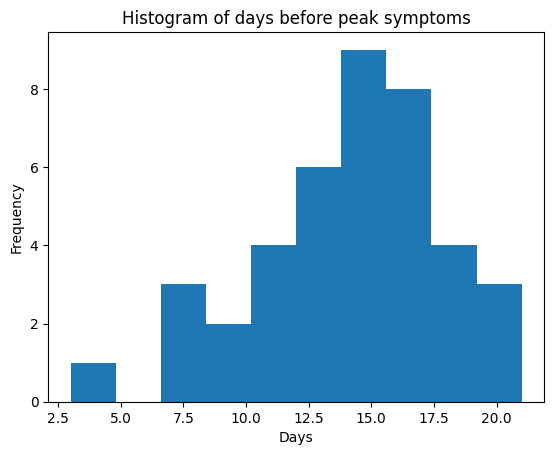

Sample mean (x-bar) = 13.85
Sample size (n) = 40
95% confidence interval for mu: (12.61, 15.09)
mu = 17 is NOT plausible (outside the confidence interval).


In [7]:
import numpy as np 
import matplotlib.pyplot as plt
from math import sqrt

days = np.array([16, 12, 14, 16, 13, 9, 15, 7, 20, 19, 11, 14, 9, 13, 11, 3, 8, 21, 16, 16, 12, 16, 14, 20, 7, 14, 18, 14, 18, 13, 11, 16, 18, 16, 11, 13, 14, 16, 15, 15])

# a) Histogram
plt.hist(days)
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.title("Histogram of days before peak symptoms")
plt.show()

# b) Sample mean
x_bar = np.mean(days)
n = len(days)

print(f"Sample mean (x-bar) = {x_bar:.2f}")
print(f"Sample size (n) = {n}")

# c) 95% Confidencr Interval 
sigma = 4
z = 1.96

margin_error = z * sigma / sqrt(n)

ci_lower = x_bar - margin_error
ci_upper = x_bar + margin_error

print(f"95% confidence interval for mu: ({ci_lower:.2f}, {ci_upper:.2f})")

# Check claim mu = 17
mu_claim = 17

if ci_lower <= mu_claim <= ci_upper:
    print("mu = 17 is plausible (inside the confidence interval).")
else:
    print("mu = 17 is NOT plausible (outside the confidence interval).")

### Exercise 3

Sulfur dioxide causes acid rain. These data were obtained on the concentration in a forest area thought to have been damaged by acid rain:
|µg/m³|52.7|43.9|41.7|71.5|47.6|55.1|62.2|56.5|33.4|61.8|54.3|50.0|45.3|63.4|53.9|65.5|66.6|70.0|52.4|38.6|46.1|44.4|60.7|56.4|
|-----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|

a) Compute $\bar{x}$, $s^2$ and $s$, the sample mean, sample variance and sample deviation.

b) Compute a 95% confidence interval on the mean. 

c) Given a national average of 20 µg/m³, is there evidence for elevated sulfur levels in the data?

In [9]:
import numpy as np 
from scipy import stats

x = np.array([52.7, 43.9, 41.7, 71.5, 47.6, 55.1, 62.2, 56.5, 33.4, 61.8, 54.3, 50.0, 45.3, 63.4, 53.9, 65.5, 66.6, 70.0, 52.4, 38.6, 46.1, 44.4, 60.7, 56.4])

# a) xbar, s^2, s
n = len(x)
xbar = x.mean()
s2 = x.var(ddof=1)
s = x.std(ddof=1)

print("------ (a) Summary ------")
print("n =", n)
print("x-bar =", xbar)
print("s^2 =", s2)
print("s =", s)

# b) 95% CI for mean 
alpha = 0.05
tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
margin = tcrit * s / np.sqrt(n)
ci_low, ci_high = xbar - margin, xbar + margin

print("\n------ (b) 95% CI for mu ------")
print("t_crit =", tcrit)
print("CI =", (ci_low, ci_high))

# c) One-sided t-test: H0: mu=20 vs H1: mu>20
mu0 = 20
t_stat = (xbar - mu0) / (s / np.sqrt(n))
p_value = 1 - stats.t.cdf(t_stat, df=n-1)

print("\n------ (c) Test mu > 20 ------")
print("t_stat =", t_stat)
print("p_value =", p_value)

if p_value < 0.05:
    print("Result: Reject H0 at 5% level (evidence mean > 20).")
else:
    print("Result: Fail to reject H0 at 5% level (not enough evidence mean > 20).")

------ (a) Summary ------
n = 24
x-bar = 53.916666666666664
s^2 = 101.47971014492754
s = 10.073713820876963

------ (b) 95% CI for mu ------
t_crit = 2.0686576104190486
CI = (np.float64(49.66291038494761), np.float64(58.17042294838572))

------ (c) Test mu > 20 ------
t_stat = 16.494120954125684
p_value = 1.5432100042289676e-14
Result: Reject H0 at 5% level (evidence mean > 20).
